# Churn Prediction — Exploratory Data Analysis

## Objective

The objective of this project is to predict, based on customer features, which customers are likely to churn from a telecom company. My initial assumption is that I would expect a relatively low churn rate, since this is a snapshot of current customers, and most people who were going to churn have likely already left. Given my assumption, I would expect minimizing false negatives to matter most: predicting a customer won't churn when they actually will is more costly to the business (a lost customer with no intervention) than predicting churn for someone who was going to stay (a wasted retention offer). 

In this notebook the objective is to understand the structure, distributions, and relationships in the Teleco Customer Churn dataset to inform cleaning and feature engineering decisions.

## Inputs
- `../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`
- Teleco Customer Churn dataset — 7043 Customers, 21 columns
- Column Description: 
    - **Customer info**: `customerID`, `gender`, `SeniorCitizen`, `Partner`, `Dependents`
    - **Account & billing**: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
    - **Services subscribed**: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
    - **Target**: `Churn`

## Output
- Key observations documented below to guide data cleaning and feature engineering
- Modified `df` with `TotalCharges` converted to `float64` and 11 missing values introduced as `NaN` placeholders (to be handled in feature engineering)

## 1.1 Setup and Imports

Importing core libraries for data manipulation, visualization, and analysis. Path constant is defined here to ensure consistent file references throughout the notebook. Warning suppression keeps the output clean.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore') # suppress outputs of warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

RAW_DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

## 1.2 load dataset

Using pandas to read the dataset and varifying the csv has been properly read into the dataframe with `.shape` and `.head()`. 

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
pd.set_option('display.max_columns', None)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Comparing against what's shown on Kaggle, the shape `(7043, 21)` confirms I've successfully imported 7043 samples and 21 columns, including the target `Churn`. The `.head()` output shows the first 5 rows, and the column names and values match what's described on Kaggle, confirming the data loaded correctly.

## 1.3 Sanity Check

To ensure the data within the dataset is as it should be, before any analysis is done, I will conduct sanity checks. I will check for any incorrect data types, missing values, any impossible or suspicious values, and unexpected categories in order to ensure that analysis can be done without inaccurate or misleading data, and so that down stream models can be trained and tested on good data. 

In [ ]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Looking at the data types of the columns and comparing to what was generated in `.head()`, all columns appear to contain the correct dtype except `TotalCharges`, which is dtype `str`. From `.head()` it looks like it should be `float`, and given that `MonthlyCharges` is `float64` but `TotalCharges` is `str`, this raises the possibility of data entry errors causing the dtype to be `str` instead of `float`. I wil first check for explicit missing values before investigating further.

To check for any missing values and to investigate whether the dtype error in `TotalCharges` is caused by missing or malformed values, I will run `.isnull().sum()` to count `NaN` entries in each column.

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

All columns return a sum of 0, meaning there are no explicit `NaN` values in the dataset. However, this does not rule out hidden missing values — since something in `TotalCharges` is causing it to be read as `str` instead of `float`, there may be non-`NaN` placeholder values (such as empty strings or spaces) that `.isnull()` would not catch. I will investigate `TotalCharges` directly to determine what those values are.

To investigate the `TotalCharges` issue, I will convert the column to numeric using `pd.to_numeric()` with `errors='coerce'`, which turns any non-numeric values into `NaN`. I will then create a boolean mask of rows where conversion failed and examine all columns at those rows to identify why these entries are not `float`.

In [3]:
converted = pd.to_numeric(df['TotalCharges'], errors = 'coerce') 
mask = converted.isna()
print(mask.sum())
df[mask]

11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Looking at the features across the 11 flagged rows, the only columns with consistent patterns are `SeniorCitizen`, `Dependents`, `tenure`, and `Churn`. However, `SeniorCitizen` and `Dependents` can be ruled out as meaningful findings — with only 11 rows and these being binary columns, the pattern is likely noise rather than a signal. `tenure`, on the other hand, makes real business sense: it represents how long an individual has been a customer, so a brand new customer (`tenure = 0`) would logically have no `TotalCharges` yet. This also explains why `Churn = No` for all 11 rows — a customer who just signed up cannot have already churned, so this is logically guaranteed rather than an independent finding. The meaningful observation here is `tenure = 0`, which explains the empty `TotalCharges` values. These are new customers with no completed billing cycle, and the blank appears to be a data entry error where `' '` was entered instead of `0.0`.

To confirm exactly what is stored in the `TotalCharges` field for these rows, I will use `repr()` to reveal the raw character content, including any invisible characters like spaces.

In [6]:
repr(df.loc[mask, 'TotalCharges'].iloc[0])

"' '"

The `repr()` output confirms that the 11 flagged `TotalCharges` entries contain a space character `' '` rather than `NaN` or `0.0`. This explains why `.isnull().sum()` returned 0 for `TotalCharges` — pandas does not treat `' '` as a missing value, only explicit `NaN`. These entries will need to be handled in feature engineering by replaing the space and converting the column to `float64`.

Since `TotalCharges` needs to be numeric for accurate analysis, I will convert it in place using `pd.to_numeric()` with `errors='coerce'`, to replace the 11 `' '` entries with `NaN` as a temporary placeholder. I will correctly handle these 11 rows (whether `0.0`, imputation, or removal) in feature engineering — `NaN` is used here to avoid assuming a value before that decision is made.

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce') 
print(df['TotalCharges'].isnull().sum())
df['TotalCharges'].dtype

11


dtype('float64')

To continue the sanity check, I will run `.describe()` to examine summary statistics for the numeric columns — checking for any impossible values (negatives, zeros where they shouldn't exist) and extreme values that fall far outside the expected range.

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


`SeniorCitizen` is heavily imbalanced — over 75% of values are 0 (non-senior), meaning the model will see very few examples of senior customers, which could introduce bias toward the majority group. `tenure` has no impossible values — a max of 72 months (~6 years) is a valid tenure for a telecom customer, though the gap between the 75th percentile (55) and max (72) suggests a right-skewed distribution with a long tail, which I expect to see confirmed in univariate analysis. `MonthlyCharges` shows a similar pattern — the min of $18.25 rules out any impossible zero or negative charges, and the gap between the 75th percentile ($89.85) and max ($118.75) again suggests a right tail rather than true outliers. `TotalCharges` follows the same pattern — min of $18.80 rules out impossible values, and the large gap between the 75th percentile ($3,794.73) and max ($8,684.80) suggests a heavily right-skewed distribution, which makes sense since long-tenure customers accumulate significantly more charges. No impossible values found in any numeric column.

To check for unexpected categories or hidden data entry errors across categorical columns, I will run `.describe(include='object')` to get an overview of unique value counts and most frequent values for all `object` columns.

In [12]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


To confirm the exact category labels in columns with 3 unique values, I will run `.value_counts()` on a sample of these columns rather than relying solely on Kaggle's documentation, which labels the third category as `other` without specifying what it represents.

In [6]:
df['InternetService'].value_counts()
df['MultipleLines'].value_counts()
df['OnlineSecurity'].value_counts()


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Columns like `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies` each have a third category representing "service not applicable" (e.g., `No internet service`, `No phone service`) 
rather than a simple yes/no choice. This is distinct from `No` — since a customer with no internet service cannot logically have online security, so these are meaningfully different categories. I will decided whether to keep them separate or combine them with `No` in feature engineering after bivariate analysis reveals whether they behave differently with respect to churn.

Summary of sanity checks' issues and observations:

- **`TotalCharges` dtype:** The column was stored as `str` due to 11 rows containing `' '` (a space character) instead of a numeric value. These were temporarily converted to `NaN` using `pd.to_numeric()` so analysis can proceed accurately — the correct handling (replacement with `0.0`, imputation, or removal) will be decided in feature engineering based on the `tenure = 0` pattern found in these rows.
- **Hidden missing values:** `.isnull().sum()` returned 0 for all columns, but the `TotalCharges` investigation revealed that pandas does not treat `' '` as `NaN` — a reminder that zero null counts do not guarantee clean data.
- **`SeniorCitizen` imbalance:** Over 75% of values are 0 (non-senior), which could introduce bias toward the majority group in downstream modeling.
- **No impossible values:** All numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`) have plausible ranges with no negative or zero values where they 
shouldn't exist.
- **Service column third categories:** Columns like `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies` contain a third category representing "service not applicable" rather than a true yes/no choice. Whether to combine this with `No` will be decided in feature engineering after bivariate analysis.

## 1.4 Target Distribution 

To understand the distribution of the target variable `Churn`, I will use `value_counts(normalize=True)` to see the proportion of each class. I am specifically looking for class imbalance, which would affect which evaluation metrics are meaningful downstream and whether any steps need to be taken to prevent the model from being biased toward the majority class.

In [8]:
print(df['Churn'].value_counts())
df['Churn'].value_counts(normalize=True)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

The target distribution is imbalanced — 73.5% of customers did not churn (`No`) and only 26.5% did (`Yes`), confirming my initial hypothesis that churn rate would be low since customers who were going to leave have likely already done so. 

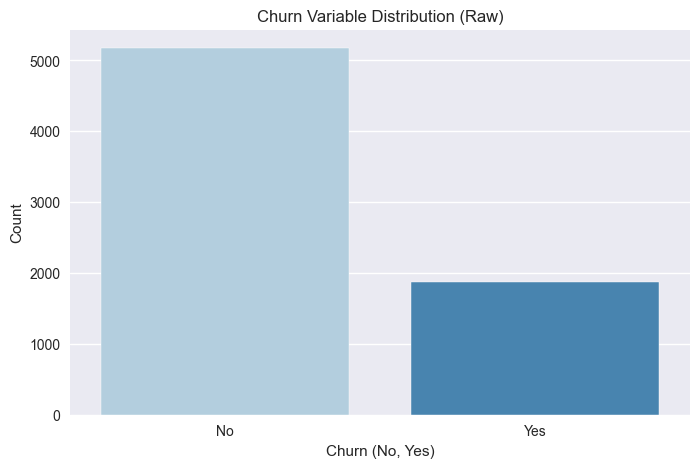

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df, palette='Blues')
plt.title('Churn Variable Distribution (Raw)')
plt.xlabel('Churn (No, Yes)')
plt.ylabel('Count')
plt.savefig('../images/target_distribution.png', bbox_inches='tight')
plt.show()

This imbalance has two immediate implications. First, a naive model that predicts `No` for every customer would achieve ~73.5% accuracy without learning anything — making accuracy an unreliable metric for this problem. Instead, I will prioritize precision, recall, F1-score, and AUC-ROC, with emphasis on recall for the positive class (`Yes`) since a false negative (missed churner) is more costly to the business than a false positive (wasted retention offer). Second, the imbalance could bias the model toward the majority class — I will address this in modeling by adjusting class weights, and will additionally consider resampling techniques like SMOTE if needed, given the minority class (~1,869 churners) is large enough to make resampling viable.

## 1.5 Univariate Analysis

To visualize and analyze the features, looking at distributions and potential outliers, I will conduct univariate analysis using a histogram with a KDE curve overlay for the continuous variables (`tenure`, `MonthlyCharges`, `TotalCharges`), and a countplot for all categorical variables (`gender`, `SeniorCistizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`).

`customerID` will not be included in univariate analysis or any downstream analysis — it only serves to distinguish between customers, adds no predictive information, and will have no impact on modeling. `Churn` is also excluded here since its distribution was already analyzed in section `1.4 Target Distribution`.

### Continuous Features:
`tenure`, `MonthlyCharges`, `TotalCharges`

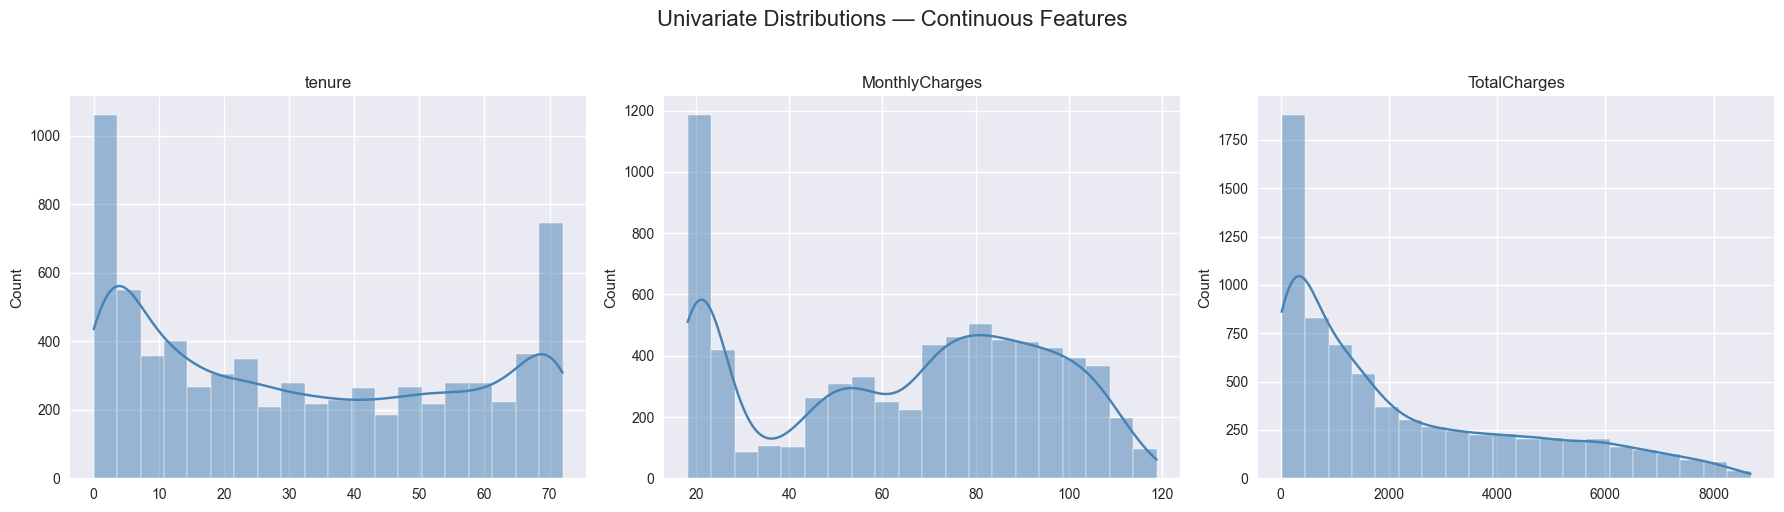

In [14]:
continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Univariate Distributions — Continuous Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/continuous_distributions.png', bbox_inches='tight')
plt.show()

**tenure:** The distribution has two peaks — the highest near 0 and a second at ~70 months — with a shallow, relatively flat section in between. The peak near 0 reflects the large number of new customers in the dataset. The drop from 0 and the flat middle section could suggest early churn (customers leaving before reaching long enure), or it could simply reflect business growth — a larger recent customer base means more people with low tenure by default. The second peak at ~70 suggests a segment of highly loyal long-term customers. These hypotheses will be investigated in bivariate analysis by comparing `tenure` distributions split by `Churn` — if churn is concentrated among low-tenure customers, that supports the early churn explanation; if churn is roughly uniform across tenure values, business growth is the more likely explanation for the dip.

**MonthlyCharges:** The distribution is bimodal with the highest peak near $20 and a second peak around $80, with a notable dip in the $40–60 range. These two peaks likely reflect two broad customer segments — a basic plan with few or no added services, and a more premium plan with multiple services. The gap between the peaks suggests customers tend to cluster toward one tier or the other rather than falling in the middle, which may reflect how the company structures its pricing. I expect bivariate analysis to show a correlation between `MonthlyCharges` and service columns like `InternetService` and `StreamingTV`.

**TotalCharges:** The distribution is heavily right-skewed with a peak near 0, consistent with the right-skewed distribution I predicted during sanity checks. This peak is likely driven by the large number of new customers in the dataset — low `tenure` customers naturally accumulate little in total charges. Additionally, the second peak seen in `tenure` at ~70 months is not reflected here, because `TotalCharges` is a product of both `tenure` and `MonthlyCharges` — a long-tenure customer on a basic plan may have similar total charges to a short-tenure customer on a premium plan, smoothing out any second peak.

### Categorical Features
`gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`

In [4]:
# change categories from 0 and 1 to no and yes for readability
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

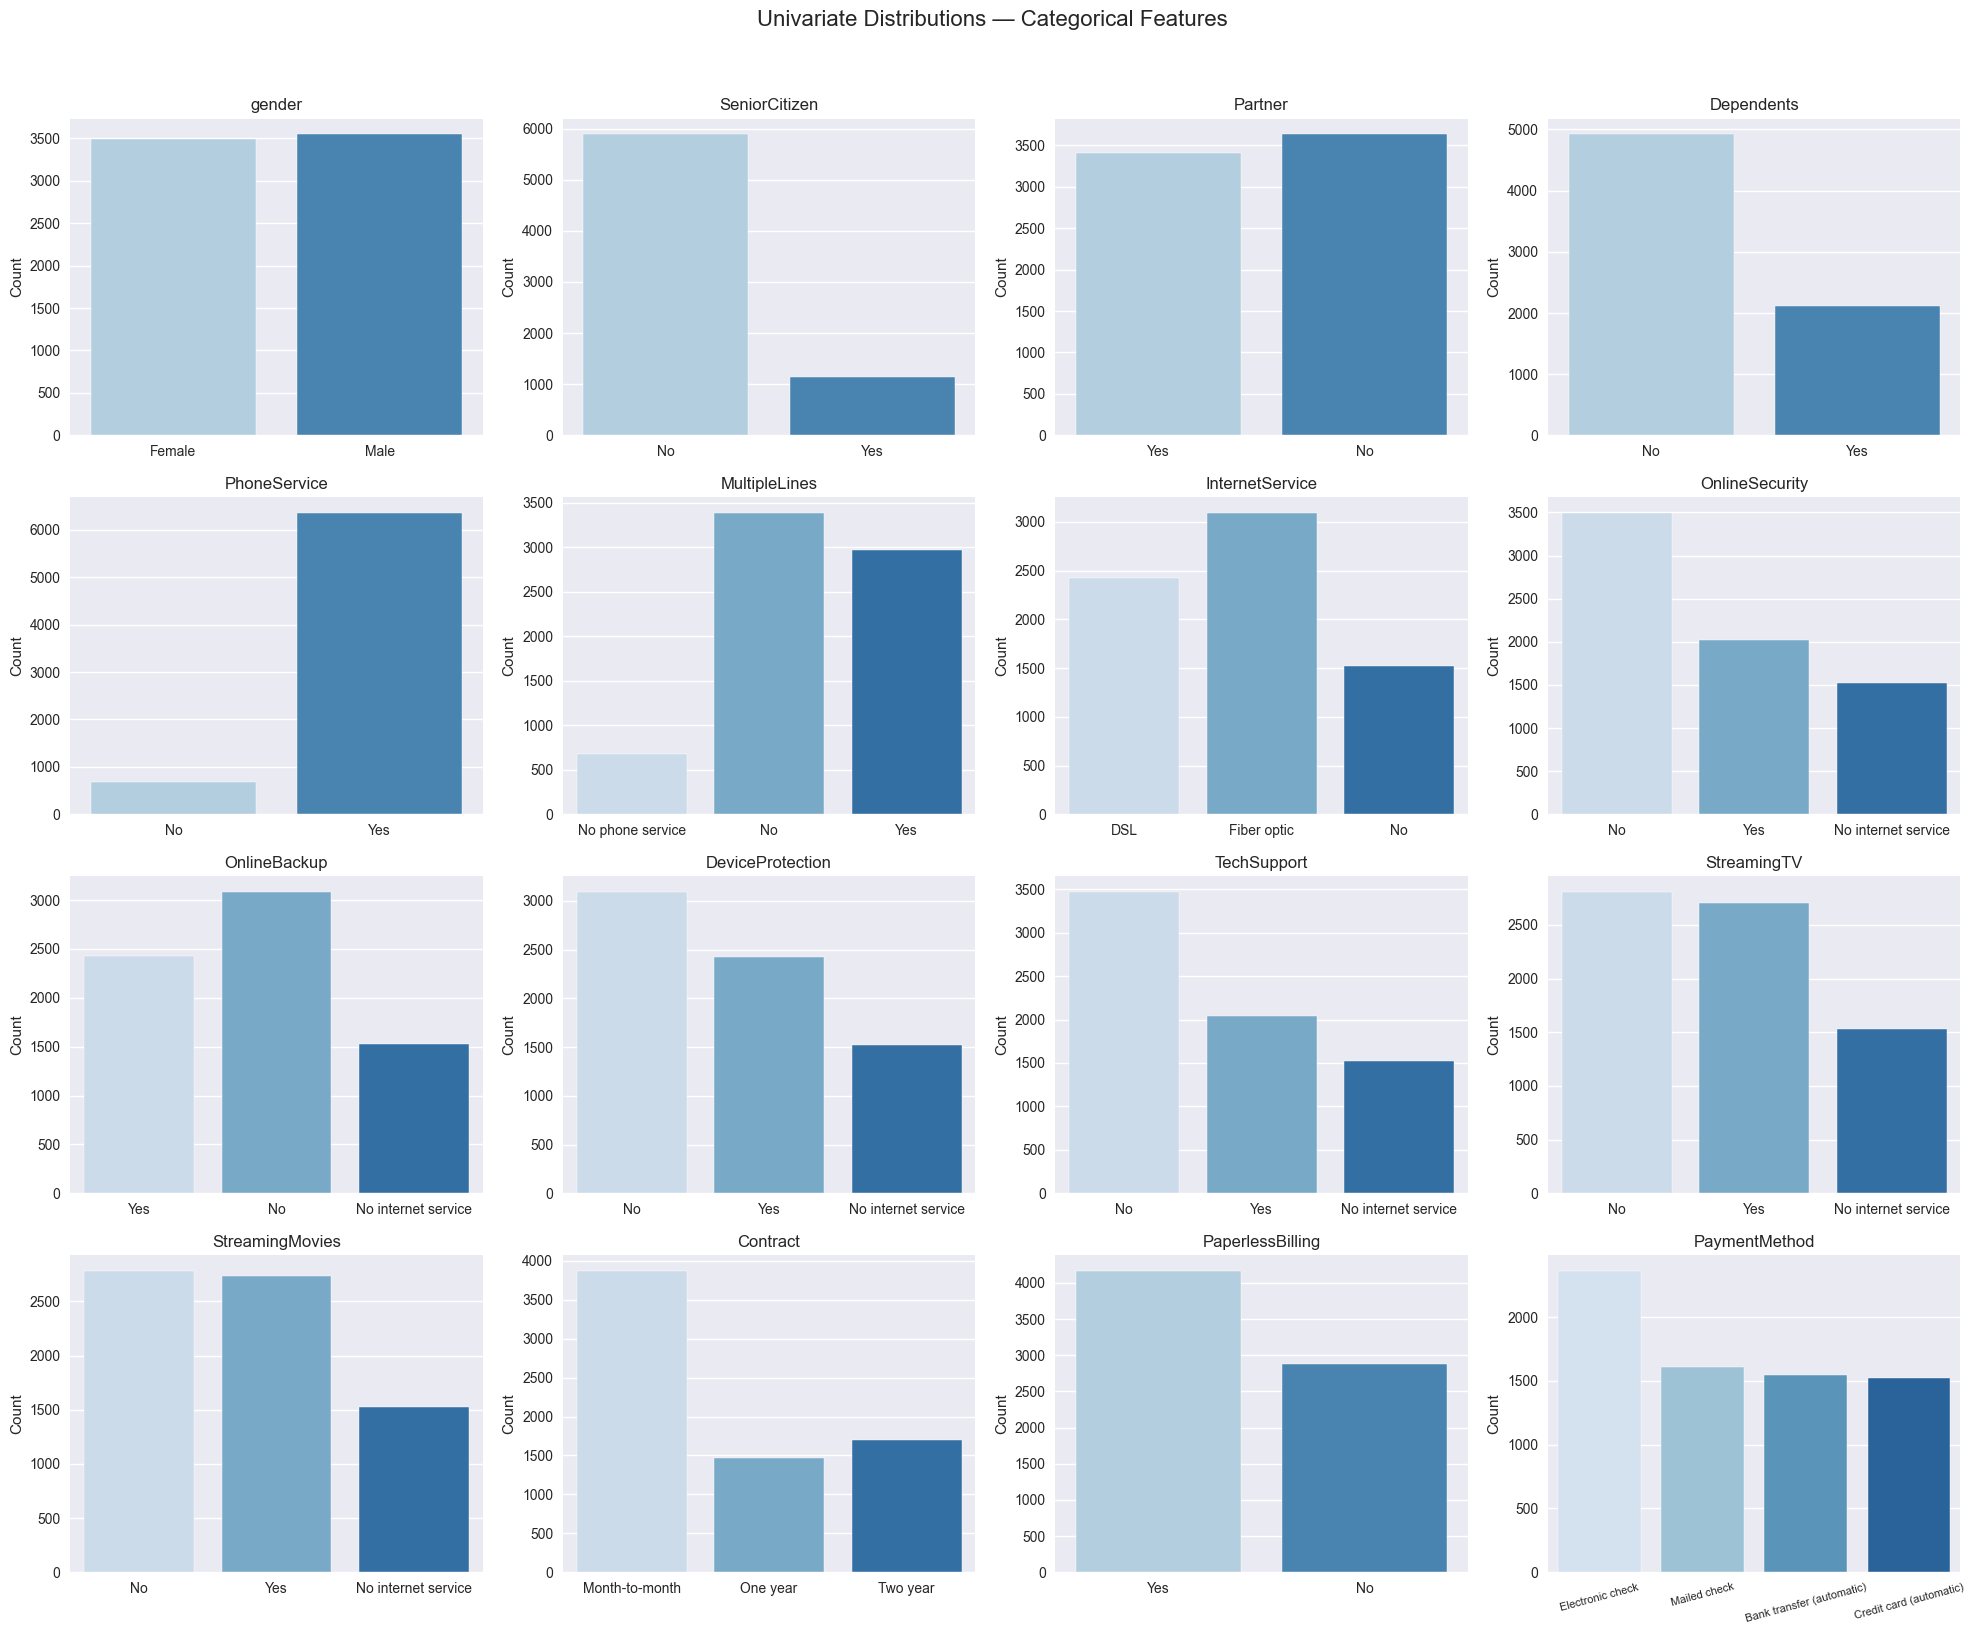

In [ ]:
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, data=df, ax=axes[i], palette='Blues')
    if feature == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=15, labelsize=8)
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Univariate Distributions — Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/categorical_distributions.png', bbox_inches='tight')
plt.show()

**gender, Partner, Dependents, PhoneService:** `gender` and `Partner` are roughly balanced, with `Male` and `No` being the slight majority respectively. `Dependents` is more skewed toward `No`, and `PhoneService` is heavily skewed toward `Yes` — expected given this is a telecom company, where having no phone service at all would be unusual.

**OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:** Across these service features, `No` is the dominant category in all of them, with a consistent `No internet service` count across each — which makes sense since customers without internet cannot subscribe to any of these add-on services. The majority of customers opting out of add-on services aligns with the low peak at ~$20 in the `MonthlyCharges` bimodal distribution, suggesting most customers are on basic plans. The second peak at ~$80 likely reflects the subset of customers who do subscribe to premium services like `Fiber optic` internet and streaming add-ons.

**Contract:** is dominated by month-to-month customers, with one-year and two-year contracts being roughly equal and significantly less common. This is worth flagging for bivariate analysis since month-to-month customers have lower switching costs and are likely easier to churn, so I expect `Contract` to be a strong predictor of churn.

**PaperlessBilling, PaymentMethod:** `PaperlessBilling` skews toward `Yes`, and `PaymentMethod` shows `Electronic check` as the most common payment method — consistent with the paperless billing dominance. The remaining three payment methods (mailed check, bank transfer automatic, credit card automatic) are roughly equal.

**SeniorCitizen:** is heavily imbalanced with the vast majority of customers being non-senior (`No`), consistent with the imbalance flagged during sanity checks.

### Summary
- **Bimodal `MonthlyCharges`**: two customer segments emerge — basic plan (~$20) and premium plan (~$80) — driven by service adoption. Most customers opt out of add-on services, explaining the dominant low-cost peak.
- **Right-skewed `TotalCharges` and `tenure`**: large proportion of new/short-tenure customers. Whether the `tenure` drop reflects early churn or business growth will be investigated in bivariate analysis.
- **`Contract` type distribution**: month-to-month dominates, which likely correlates with higher churn — to be confirmed in bivariate analysis.
- **`InternetService` skews toward Fiber optic**: the premium tier, consistent with the upper peak in `MonthlyCharges`.
- **Service columns**: majority `No` across all add-on services, with a consistent `No internet service` count — suggesting a large basic-plan customer segment.
- **`SeniorCitizen` heavily imbalanced**: ~85% non-senior, flagged as potential source of model bias in sanity checks.

## 1.6 Bivariate Analysis

To visualize and analyze each feature's relationship with `Churn`, I will conduct bivariate analysis using a violin plot split by `Churn` for the continuous variables (`tenure`, `MonthlyCharges`, `TotalCharges`), and a countplot split by `Churn` (using `hue`) for all categorical variables (`gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`).

### Continuous Features

To investigate how the continuous features relate to churn, I will use violin plots to visualize each feature's distribution split by `Churn`. I am using violin plots instead of boxplots in order to see the full distribution shape for each group, not just summary statistics. This is more useful given that `MonthlyCharges` was bimodal in univariate analysis. This will help confirm or refute the tenure-vs-churn hypothesis made in univariate analysis — whether the tenure drop reflects early churn or business growth.

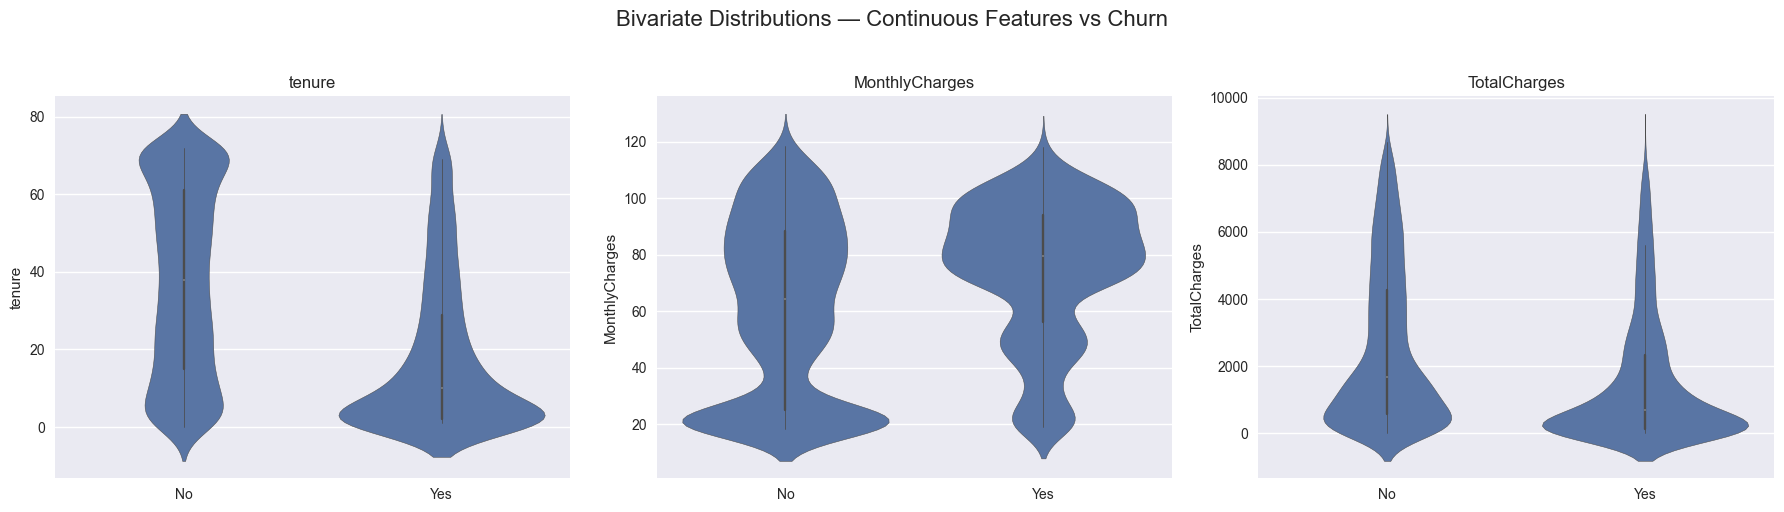

In [4]:
continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.violinplot(x='Churn', y=feature, data=df, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

fig.suptitle('Bivariate Distributions — Continuous Features vs Churn', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/bivariate_continuous.png', bbox_inches='tight')
plt.show()

For `tenure`, the `Yes` (churned) violin is wide at low tenure and narrows sharply at high tenure. This means churned customers are concentrated in their first several months, which confirms the early-churn hypothesis from univariate analysis — the dip seen near tenure 0–10 is driven by customers leaving early, not simply by a growing customer base.

For `MonthlyCharges`, the `No` (didn't churn) violin is widest at low charges (~$20), while `Yes` is widest in the mid-to-high range (~$70–100). This suggests churned customers tend to pay more per month, which makes intuitive sense — lower prices give customers less incentive to leave, while higher prices increase the incentive to switch providers.

`TotalCharges` shows a similar pattern to `tenure`, with both groups widest at the low end and `Yes` skewing even lower than `No`. This is likely a consequence of the `tenure` finding rather than an independent signal, since `TotalCharges` is partly a function of `tenure` — customers who churn early haven't had time to accumulate high total charges. This relationship will be confirmed more directly in correlation analysis.

### Categorical Features

To examine how each categorical feature relates to `Churn`, I will use a countplot with `hue='Churn'` for all categorical variables. This will help confirm or refute the `Contract`-vs-`churn` hypothesis from univariate analysis — whether month-to-month contracts are associated with higher `Churn` — and reveal which other categorical features show a meaningful split between churned and non-churned customers.

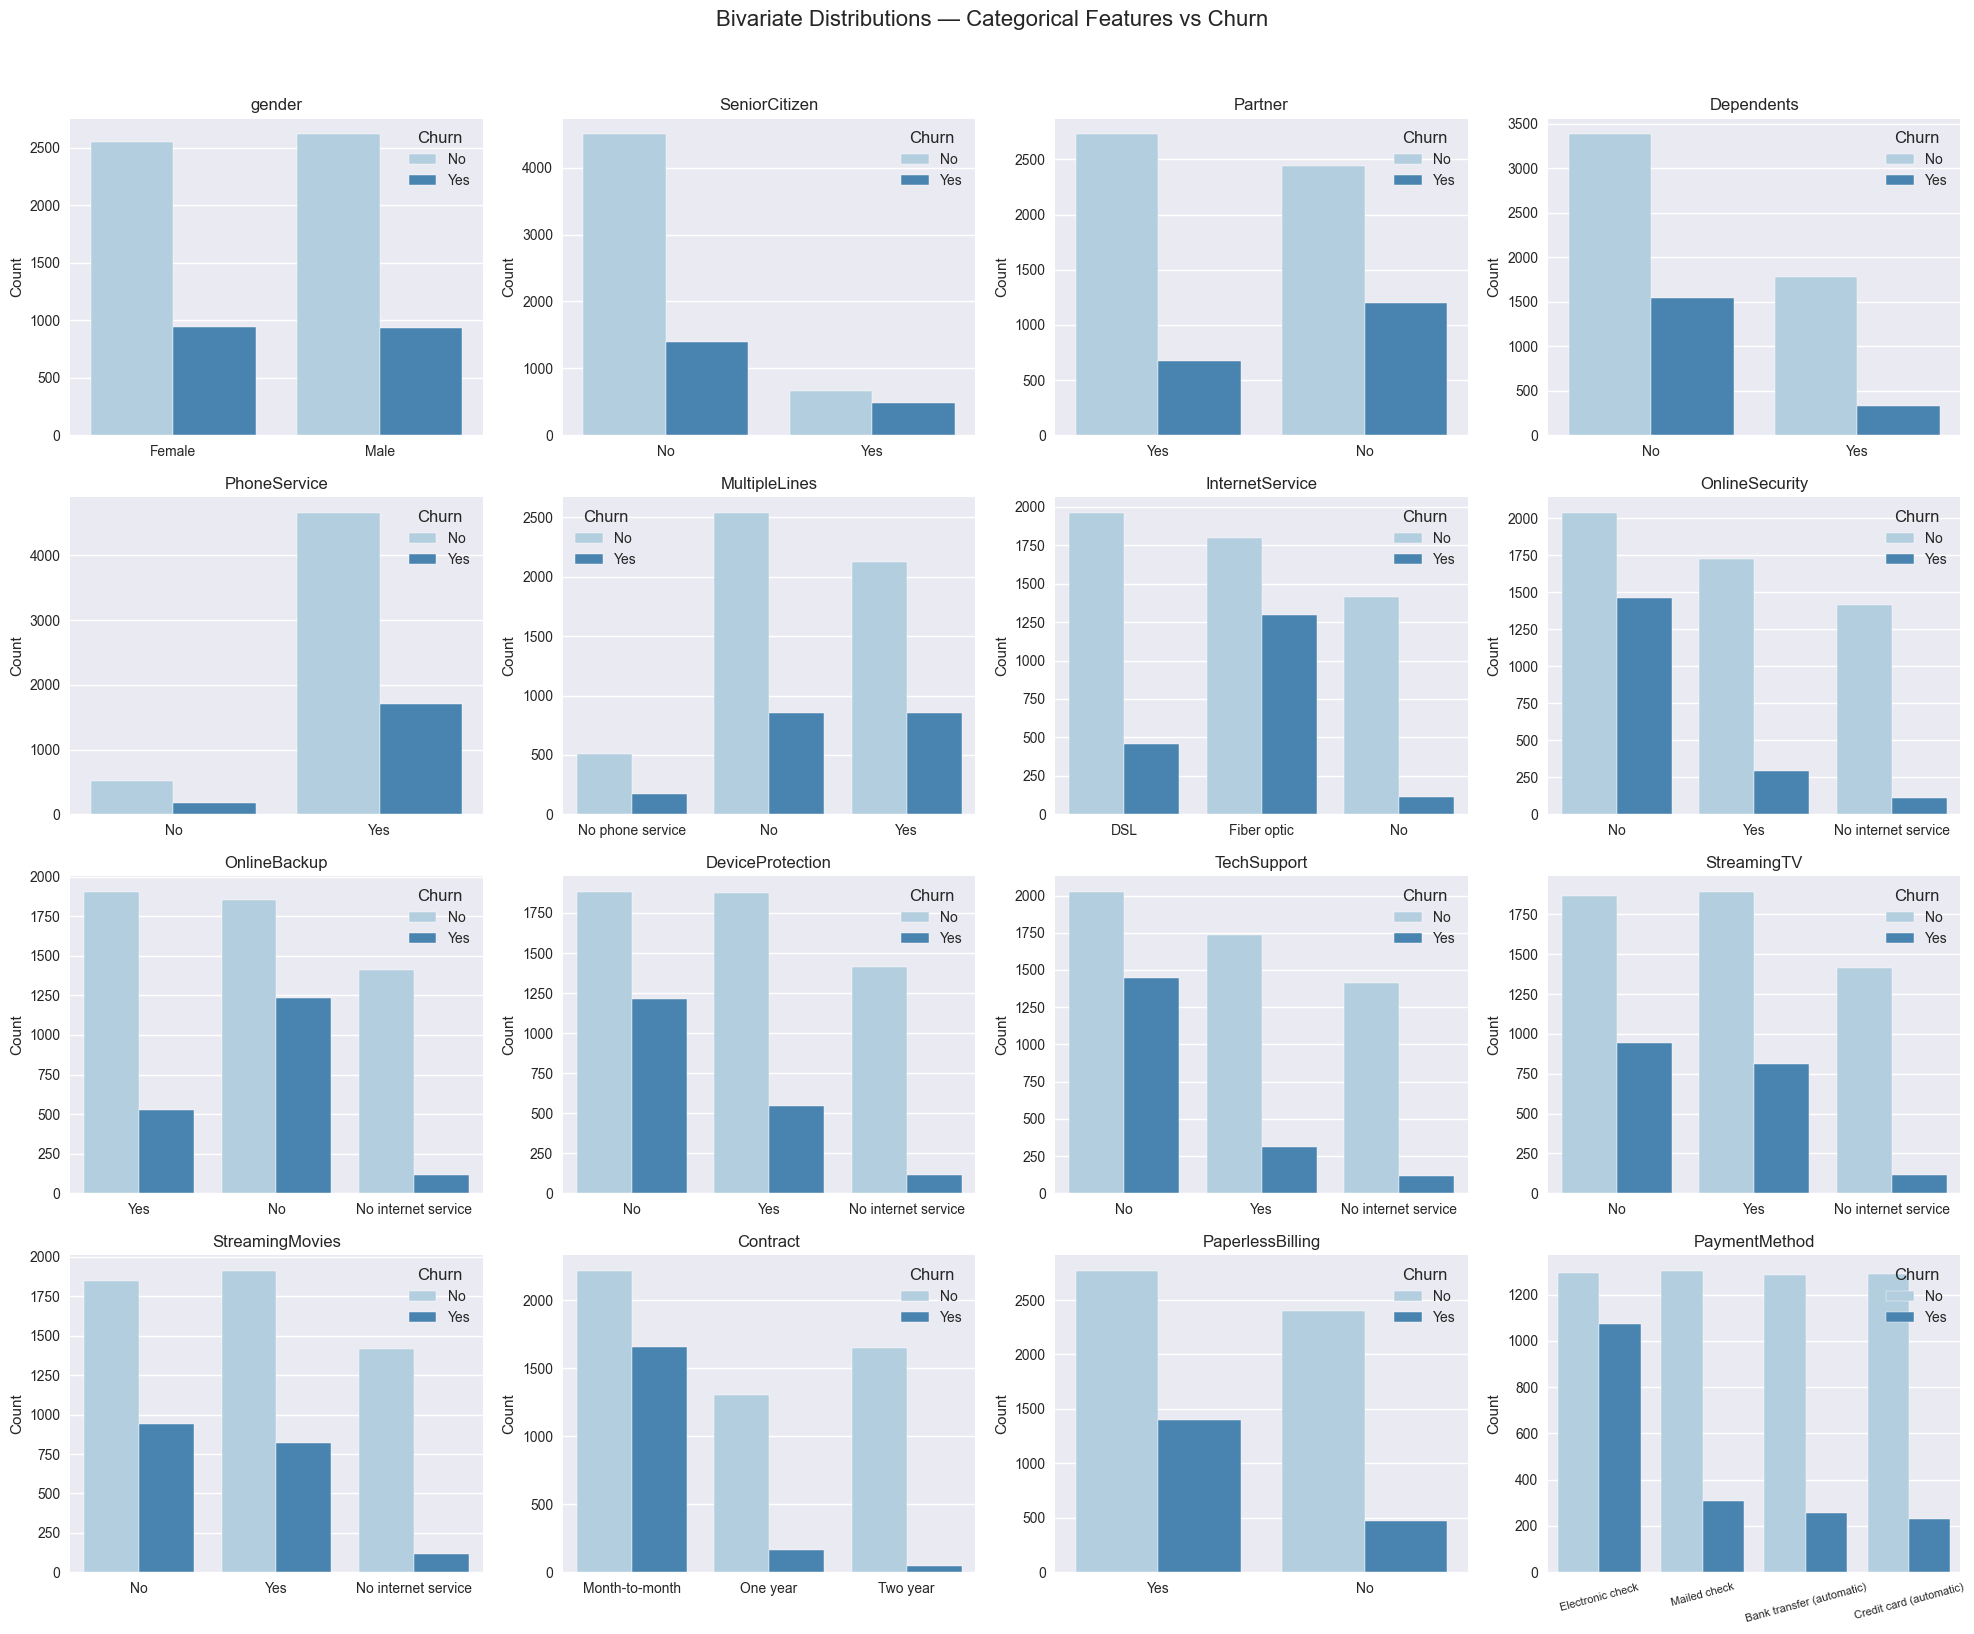

In [14]:
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue='Churn', data=df, ax=axes[i], palette='Blues')
    if feature == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=15, labelsize=8)
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Bivariate Distributions — Categorical Features vs Churn', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/bivariate_categorical.png', bbox_inches='tight')
plt.show()

**Demographic features** (`gender`, `SeniorCitizen`, `Partner`, `Dependents`): `gender` shows nearly equal churn rates across Male and Female — not a useful signal. `SeniorCitizen` shows a proportionally higher churn rate for seniors, worth investigating further with actual rates. `Partner` shows a higher churn rate for customers without a partner — a possible explanation is that partnered customers may share plans or have dual income, making them less likely to churn. `Dependents` shows a higher churn rate for customers without dependents — those who are dependents likely have no individual choice in whether to churn, whereas independent customers make that decision themselves.

**Phone & line features** (`PhoneService`, `MultipleLines`): `PhoneService` appears visually misleading due to the large size difference between `Yes` and `No` categories — churn rates appear roughly proportional, this will be confirmed with `pd.crosstab`. `MultipleLines` shows similar churn rates for `Yes` and `No` — a weak signal.

**Internet & add-on service features** (`InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`): `InternetService` appears to be a strong signal — Fiber optic customers show a proportionally high churn rate, likely because Fiber optic is more expensive, increasing the incentive to switch providers. Across `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, and `TechSupport`, customers without the service (`No`) consistently show a higher churn rate than those with the service (`Yes`) — suggesting that customers more invested in add-on services are less likely to leave. However, these features show similar patterns to each other, raising the possibility of redundancy — correlation will be investigated later to determine which features can be dropped. `StreamingTV` and `StreamingMovies` show nearly identical plots with similar churn rates for both `Yes` and `No` — weak signals and likely redundant with each other.

**Account & billing features** (`Contract`, `PaperlessBilling`, `PaymentMethod`): `Contract` is the strongest signal found so far — month-to-month customers have a visually high churn rate compared to one-year and two-year contracts, which makes intuitive sense since month-to-month customers have more frequent opportunities to churn. `PaperlessBilling` shows a higher churn rate for `Yes` — a moderate signal. `PaymentMethod` shows that electronic check has a significantly higher churn rate compared to the other three payment methods, which are roughly equal and low. A likely explanation is that electronic check is more convenient for month-to-month customers, suggesting a possible confounding relationship between `PaymentMethod` and `Contract` that will need to be investigated in correlation analysis.

To avoid relying solely on visual interpretation — which can be misleading when category sizes differ significantly — I will use `pd.crosstab` with `normalize='index'` to confirm the actual churn rate within each category for all categorical features. This ensures my feature ranking is based on numeric evidence rather than just visual assumptions alone.

In [15]:
for feature in categorical_features:
    print(f"\n{feature}:")
    print(pd.crosstab(df[feature], df['Churn'], normalize='index').round(3))


gender:
Churn      No    Yes
gender              
Female  0.731  0.269
Male    0.738  0.262

SeniorCitizen:
Churn             No    Yes
SeniorCitizen              
No             0.764  0.236
Yes            0.583  0.417

Partner:
Churn       No    Yes
Partner              
No       0.670  0.330
Yes      0.803  0.197

Dependents:
Churn          No    Yes
Dependents              
No          0.687  0.313
Yes         0.845  0.155

PhoneService:
Churn            No    Yes
PhoneService              
No            0.751  0.249
Yes           0.733  0.267

MultipleLines:
Churn                No    Yes
MultipleLines                 
No                0.750  0.250
No phone service  0.751  0.249
Yes               0.714  0.286

InternetService:
Churn               No    Yes
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074

OnlineSecurity:
Churn                   No    Yes
OnlineSecurity                   
No                   

### Feature Ranking

**Strong predictors** (large churn rate difference between categories):
- `Contract`: month-to-month 42.7% vs two-year 2.8% — ~15x difference confirming the hypothesis from univariate analysis
- `InternetService`: Fiber optic 41.9% vs No internet 7.4% — ~5x difference, likely driven by the higher cost of Fiber optic plans
- `OnlineSecurity`: No 41.8% vs Yes 14.6% — customers without online security are nearly 3x more likely to churn
- `TechSupport`: No 41.6% vs Yes 15.2% — nearly identical pattern to `OnlineSecurity`, raising the possibility these are redundant features
- `OnlineBackup`: No 39.9% vs Yes 21.5% — meaningful difference, consistent with the pattern across add-on services
- `DeviceProtection`: No 39.1% vs Yes 22.5% — similar pattern to `OnlineBackup`
- `PaymentMethod`: Electronic check 45.3% vs Credit card automatic 15.2% — electronic check is the dominant signal, the other three methods are roughly equal and low

**Moderate predictors** (noticeable but smaller churn rate difference):
- `SeniorCitizen`: Yes 41.7% vs No 23.6% — nearly double the churn rate for seniors, stronger than initally assumed from the visual alone
- `Partner`: No 33.0% vs Yes 19.7% — meaningful difference, possibly explained by shared plans or dual income reducing churn incentive
- `Dependents`: No 31.3% vs Yes 15.5% — dependents have limited individual choice in churning, independent customers churn at double the rate
- `PaperlessBilling`: Yes 33.6% vs No 16.3% — moderate signal, likely correlated with `Contract` and `PaymentMethod`

**Weak predictors** (negligible churn rate difference):
- `gender`: Female 26.9% vs Male 26.2% — essentially no difference, not a useful signal
- `PhoneService`: No 24.9% vs Yes 26.7% — negligible difference, confirms visual was misleading due to category size
- `MultipleLines`: Yes 28.6% vs No 25.0% vs No phone service 24.9% — small differences, weak signal
- `StreamingTV`: No 33.5% vs Yes 30.1% — small difference, weak signal
- `StreamingMovies`: No 33.7% vs Yes 29.9% — nearly identical to `StreamingTV`, likely redundant

**To investigate in correlation analysis:**
- Potential redundancy among `OnlineSecurity`, `TechSupport`, `OnlineBackup`, and `DeviceProtection` — these show similar churn patterns and may be proxies for the same underlying customer behavior (service adoption/investment)
- Potential redundancy between `StreamingTV` and `StreamingMovies` — nearly identical churn rates and distributions
- Potential confounding between `PaymentMethod` (electronic check) and `Contract` (month-to-month) — electronic check customers are likely disproportionately month-to-month, so the payment method signal may be driven by contract type
- `PaperlessBilling` correlation with `Contract` and `PaymentMethod` — all three account/billing features may be measuring overlapping customer segments

## 1.7 Correlation Analysis